In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df_exposure = pd.read_csv("Data/exposure_and_game_info/exposure_results_2025_26.csv")
df_metadata = pd.read_csv("Data/urls/game_highlight_urls_2025_26.csv")
df_game_info = pd.read_csv("Data/exposure_and_game_info/nba_games_2025-26.csv")

df = pd.merge(df_exposure, df_metadata.drop(columns=['game_id', 'title', 'url']), on="video_id", how='left')
df = pd.merge(df, df_game_info[['GAME_ID', 'HOME_TEAM_ID', "HOME_TEAM_NAME", 'AWAY_TEAM_ID', "AWAY_TEAM_NAME", 'GAME_DATE']], left_on='game_id', right_on='GAME_ID', how='left')

display(df.head())
print(df.shape)

,game_id,video_id,exposure_zone,exposure_seconds,total_detections,qi_score_avg,qi_score_std,size_score_avg,size_score_std,sov_weighted_avg,sov_weighted_std,dist_score_avg,dist_score_std,conf_avg,conf_std,laplacian_avg,laplacian_std,dist_raw_pct_avg,dist_raw_pct_std,area_pct_avg,area_pct_std,video_url,channel,duration,view_count,like_count,comment_count,GAME_ID,HOME_TEAM_ID,HOME_TEAM_NAME,AWAY_TEAM_ID,AWAY_TEAM_NAME,GAME_DATE
0,22500409,IrpfL0OcIuI,back-court-logo,490.49,2450,0.2269,0.1598,0.4802,0.0349,0.8812,0.0389,0.5335,0.3653,0.8767,0.0243,738.72,139.23,25.35,18.41,0.734,0.117,https://www.youtube.com/watch?v=IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0,22500409,1610612766,Charlotte Hornets,1610612764,Washington Wizards,2025-12-23
1,22500409,IrpfL0OcIuI,basket-logo,487.09,12868,0.0359,0.0511,0.1899,0.1658,0.4336,0.1405,0.3724,0.3075,0.8900,0.0653,1748.04,1297.65,34.03,18.67,0.160,0.153,https://www.youtube.com/watch?v=IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0,22500409,1610612766,Charlotte Hornets,1610612764,Washington Wizards,2025-12-23
2,22500409,IrpfL0OcIuI,mid-court-logo,524.32,2796,0.2290,0.2363,0.7568,0.1802,0.9195,0.0897,0.3224,0.3188,0.8809,0.0399,1050.29,255.97,35.83,17.35,2.041,1.066,https://www.youtube.com/watch?v=IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0,22500409,1610612766,Charlotte Hornets,1610612764,Washington Wizards,2025-12-23
3,22500409,IrpfL0OcIuI,side-court-led-logo,530.13,4461,0.1519,0.1514,0.4630,0.1306,0.7371,0.1402,0.4145,0.3186,0.8999,0.0448,1471.30,1085.24,30.68,17.19,0.833,2.492,https://www.youtube.com/watch?v=IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0,22500409,1610612766,Charlotte Hornets,1610612764,Washington Wizards,2025-12-23
4,22500409,IrpfL0OcIuI,side-court-logo,526.93,2683,0.1459,0.0945,0.4555,0.0350,0.6669,0.0323,0.4824,0.3094,0.8825,0.0291,1167.64,205.33,25.45,12.93,0.653,0.101,https://www.youtube.com/watch?v=IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0,22500409,1610612766,Charlotte Hornets,1610612764,Washington Wizards,2025-12-23


(8369, 33)


          GENERAL STATISTICS

Global
  Total Value      : $  16,439,676.23
  Total Videos     :           1,675
  Total Games      :             524

AVERAGES PER GAME
  Value/game       : $       9,539.73

DAILY AVERAGES
  Games/day        :            6.89
  Value/day        : $      65,773.94
  Analysis Period  :              76 days


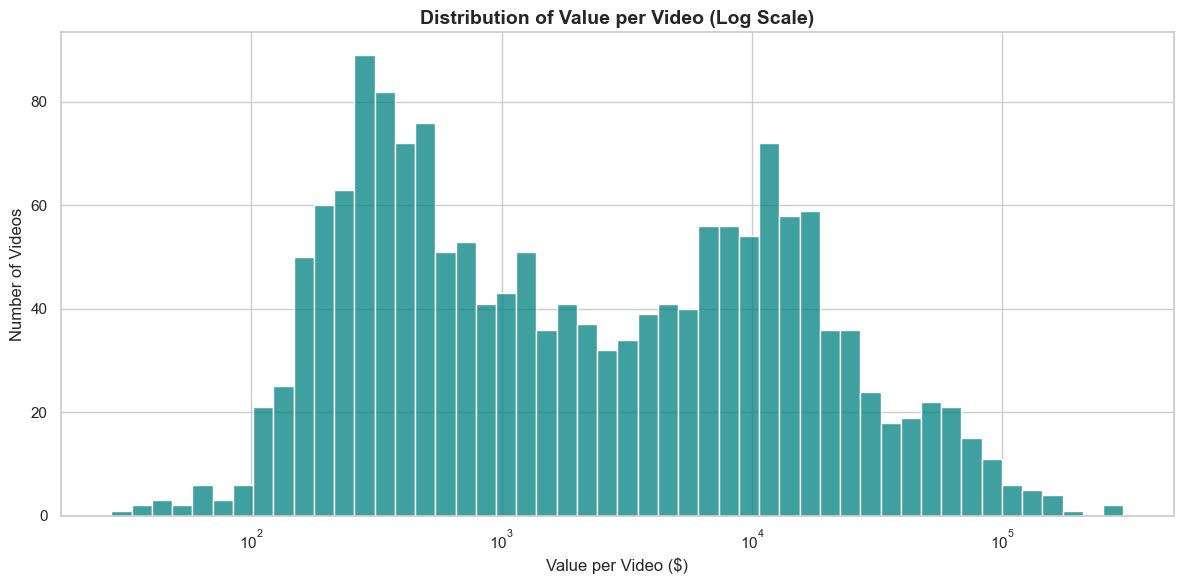

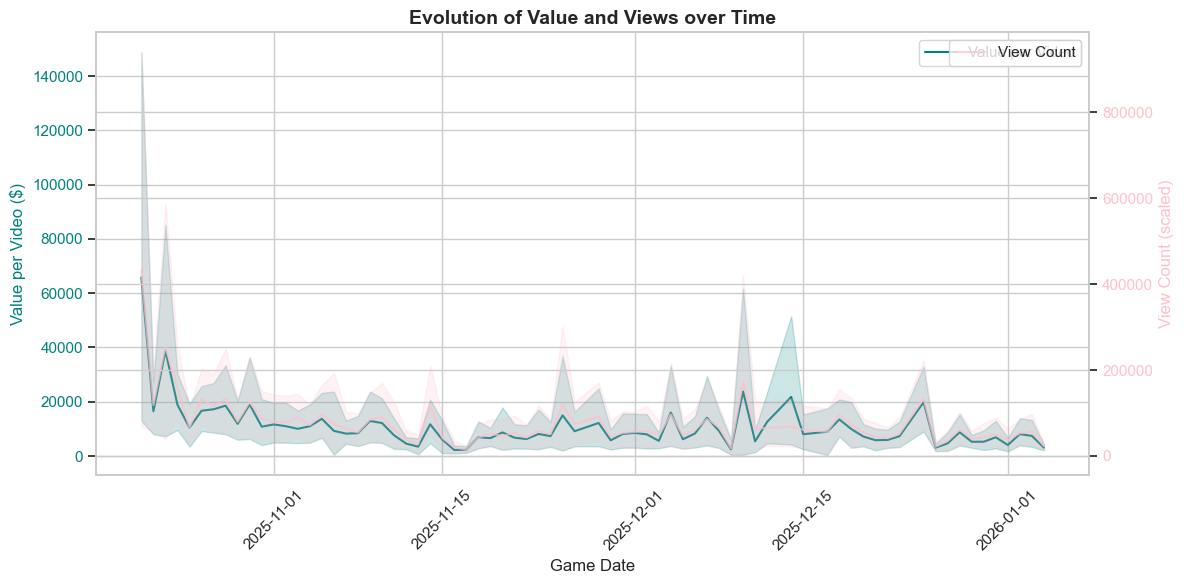

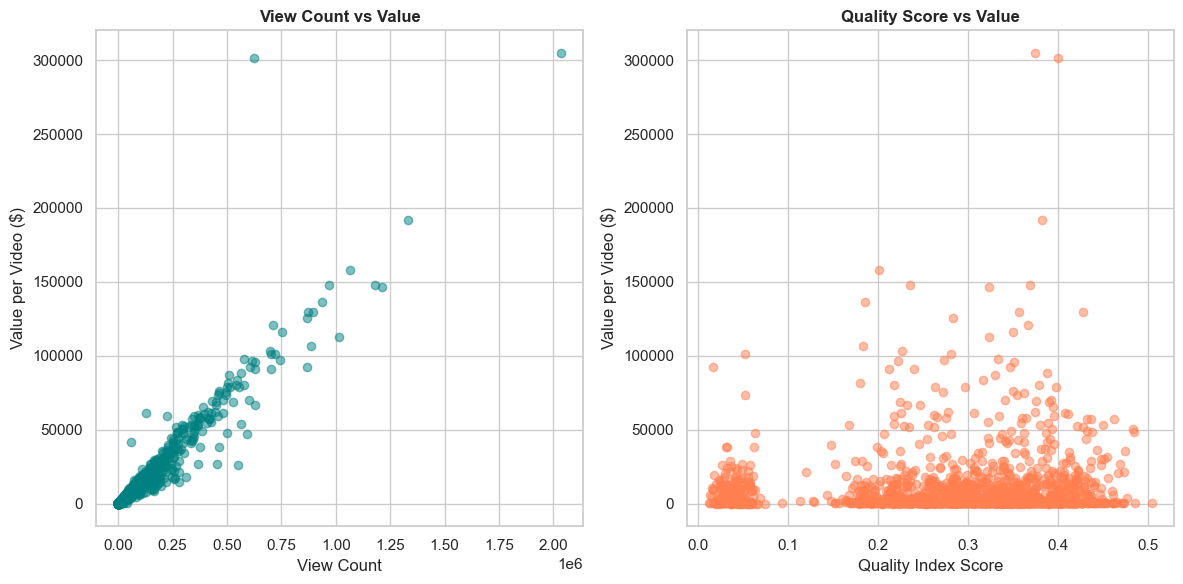


          TOP 10 MOST VALUED GAMES


Total Views  Total Value ($)  \
HOME_TEAM_NAME        AWAY_TEAM_NAME                                         
Phoenix Suns          Los Angeles Lakers          1350179    439394.462135   
Los Angeles Lakers    Golden State Warriors       2406255    365420.902080   
                      San Antonio Spurs           2377262    348052.164561   
Golden State Warriors Memphis Grizzlies           1765626    256657.325742   
                      Denver Nuggets              1633824    248627.585786   
Utah Jazz             Los Angeles Lakers          1682077    241854.497795   
Los Angeles Lakers    Minnesota Timberwolves      1644266    206829.361881   
                      Memphis Grizzlies           1280304    201777.082753   
Golden State Warriors Phoenix Suns                1324597    201235.398389   
Memphis Grizzlies     Los Angeles Lakers          1420980    199345.759103   

                                              Avg Quality Score  Game Date  
HOME_TEAM_NAME        AWAY_TEAM_NAME                                        
Phoenix Suns          Los Angeles Lakers               0.329718 2025-12-23  
Los Angeles Lakers    Golden State Warriors            0.174875 2025-10-21  
                      San Antonio Spurs                0.236357 2025-12-10  
Golden State Warriors Memphis Grizzlies                0.198325 2025-10-27  
                      Denver Nuggets                   0.294125 2025-10-23  
Utah Jazz             Los Angeles Lakers               0.253243 2025-12-18  
Los Angeles Lakers    Minnesota Timberwolves           0.265380 2025-10-24  
                      Memphis Grizzlies                0.277600 2026-01-02  
Golden State Warriors Phoenix Suns                     0.294300 2025-12-20  
Memphis Grizzlies     Los Angeles Lakers               0.254960 2025-10-31

In [3]:
# =============================================================================
# DATA PREPARATION
# =============================================================================

# Cost Per View (CPV) - the monetary value per view
CPV = 0.00033

# Convert game date to datetime format
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# Calculate readability score using sigmoid function
df['readability_score'] = df['laplacian_avg'].apply(
    lambda x: 1 / (1 + np.exp(-0.05 * (x - 100)))
)

# Calculate value per logo per video based on multiple factors
df['value_per_logo_per_video'] = (
    df['view_count'] * 
    CPV * 
    df['exposure_seconds'] * 
    df['qi_score_avg'] * 
    df['readability_score']
)

# Aggregate value per video
value_per_video = df.groupby('video_id')["value_per_logo_per_video"].sum()
df['value_per_video'] = df['video_id'].map(value_per_video)

# Aggregate value per game
value_per_game = df.groupby('game_id')['value_per_video'].sum()
df['value_per_game'] = df['game_id'].map(value_per_game)

# Create deduplicated video dataset
df_videos = df.drop_duplicates(subset='video_id')

# Calculate key metrics
nb_games = df_videos['game_id'].nunique()
total_days = (df_videos['GAME_DATE'].max() - df_videos['GAME_DATE'].min()).days + 1
games_per_day = nb_games / total_days
total_value = df_videos['value_per_logo_per_video'].sum()
value_per_day = total_value / total_days

# =============================================================================
# GENERAL STATISTICS
# =============================================================================

print("=" * 50)
print("          GENERAL STATISTICS")
print("=" * 50)

print("\nGlobal")
print(f"  Total Value      : ${df['value_per_logo_per_video'].sum():>15,.2f}")
print(f"  Total Videos     : {len(df_videos):>15,}")
print(f"  Total Games      : {nb_games:>15,}")

print("\nAVERAGES PER GAME")
print(f"  Value/game       : ${df_videos['value_per_logo_per_video'].sum() / nb_games:>15,.2f}")

print("\nDAILY AVERAGES")
print(f"  Games/day        : {games_per_day:>15.2f}")
print(f"  Value/day        : ${value_per_day:>15,.2f}")
print(f"  Analysis Period  : {total_days:>15} days")
print("=" * 50)

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# 1. Distribution of value per video (Logarithmic scale)
plt.figure(figsize=(12, 6))
sns.histplot(df_videos['value_per_video'], bins=50, log_scale=True, color='teal')
plt.title("Distribution of Value per Video (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Value per Video ($)")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

# 2. Temporal evolution of value and views
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot value per video
color = 'teal'
ax1.set_xlabel('Game Date', fontsize=12)
ax1.set_ylabel('Value per Video ($)', color=color, fontsize=12)
sns.lineplot(x=df_videos['GAME_DATE'], y=df_videos['value_per_video'], 
             color=color, ax=ax1, label='Value per Video')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Create second y-axis for view count
ax2 = ax1.twinx()
color = 'pink'
ax2.set_ylabel('View Count (scaled)', color=color, fontsize=12)
sns.lineplot(x=df_videos['GAME_DATE'], y=df_videos['view_count'], 
             color=color, ax=ax2, label='View Count', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Evolution of Value and Views over Time", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# 3. Correlation between metrics
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(df_videos['view_count'], df_videos['value_per_video'], 
            alpha=0.5, color='teal')
plt.xlabel('View Count')
plt.ylabel('Value per Video ($)')
plt.title('View Count vs Value', fontweight='bold')

plt.subplot(1, 2, 2)
plt.scatter(df_videos['qi_score_avg'], df_videos['value_per_video'], 
            alpha=0.5, color='coral')
plt.xlabel('Quality Index Score')
plt.ylabel('Value per Video ($)')
plt.title('Quality Score vs Value', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# TOP GAMES
# =============================================================================

print("\n" + "=" * 50)
print("          TOP 10 MOST VALUED GAMES")
print("=" * 50)

top_games = (df_videos.groupby(['HOME_TEAM_NAME', 'AWAY_TEAM_NAME'])
             .agg({
                 'view_count': 'sum', 
                 'value_per_video': 'sum',
                 'qi_score_avg': 'mean',
                 'GAME_DATE': 'first'
             })
             .sort_values(by='value_per_video', ascending=False)
             .head(10))

# Format the output
top_games = top_games.rename(columns={
    'view_count': 'Total Views',
    'value_per_video': 'Total Value ($)',
    'qi_score_avg': 'Avg Quality Score',
    'GAME_DATE': 'Game Date'
})

display(top_games)